# Assignment 3

This notebook shows how to build an interactive dashboard using IMF economic data. The goal is to help the reader understand how to combine multiple chart types and add interactivity using Python.

**Data:** IMF World Economic Outlook, October 2025

---
## Section 1: Visualization Technique

I use four chart types. Each one answers a different question.

- **Choropleth map** — shows which countries are growing. Good for a quick geographic overview. Not good for reading exact numbers.
- **Bubble chart** — plots growth (x) vs inflation (y), with bubble size showing GDP. Useful for spotting inflation risk. Countries in the top-right area may be overheating.
- **Scatter plot** — GDP per capita (x) vs government debt (y). Shows if richer countries are also carrying more debt.
- **Line chart** — shows how growth and inflation changed over time for one country. This is the interactive part — the user picks a country and the chart updates.

The four charts work together. The map gives a first look → the bubble chart checks risk → the scatter plot checks fiscal health → the line chart lets the user dig into any country they find interesting.

---
## Section 1: Visualization Library

**Plotly**
- Is open source library
- Made by Plotly Technologies Inc. (Montreal, Canada)
- Makes interactive charts (hover, zoom, click) that work directly in a notebook
- Install: `pip install plotly`

**ipywidgets**
- Is open source library
- Made by Project Jupyter
- Adds dropdowns and sliders to control what the charts show
- Install: `pip install ipywidgets`

I chose this combination because both work in Google Colab and Jupyter without a web server. Plotly makes interactive charts. ipywidgets adds dropdowns and sliders. When the user changes them, the chart changes too.

Limitation: the interactivity only works in a live notebook. It does not work in a saved HTML.

In [45]:
import pandas as pd
import requests
import urllib.request
import plotly.express as px
import ipywidgets as widgets
from ipywidgets import interact, interactive_output
# !pip install --upgrade openpyxl
# !pip install plotly
# !pip install ipywidgets

## Data Loading

Please go to the official IMF website below and follow these steps to download “WEOOct2025all.xlsx”:

1. Open this page:
https://www.imf.org/en/publications/weo/issues/2025/10/14/world-economic-outlook-october-2025
2. Click **DATA TOOLS**
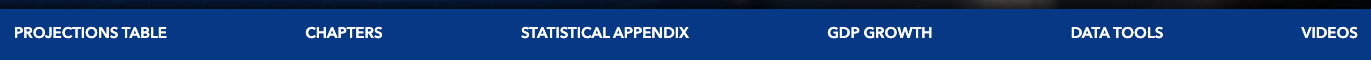

3. Click **OCTOBER 2025 DATABASE**
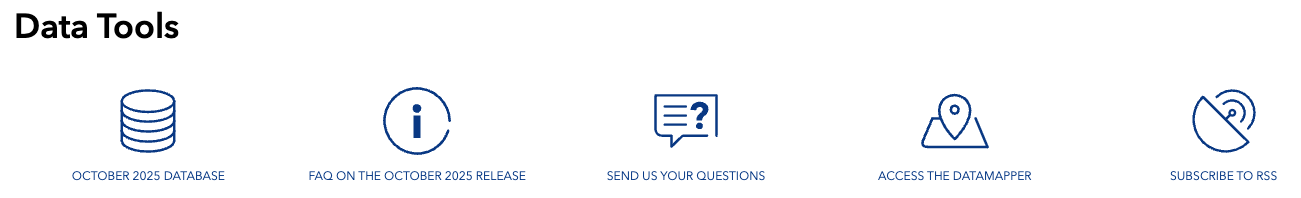

4. Click **October 2025 WEO Dataset in Excel**
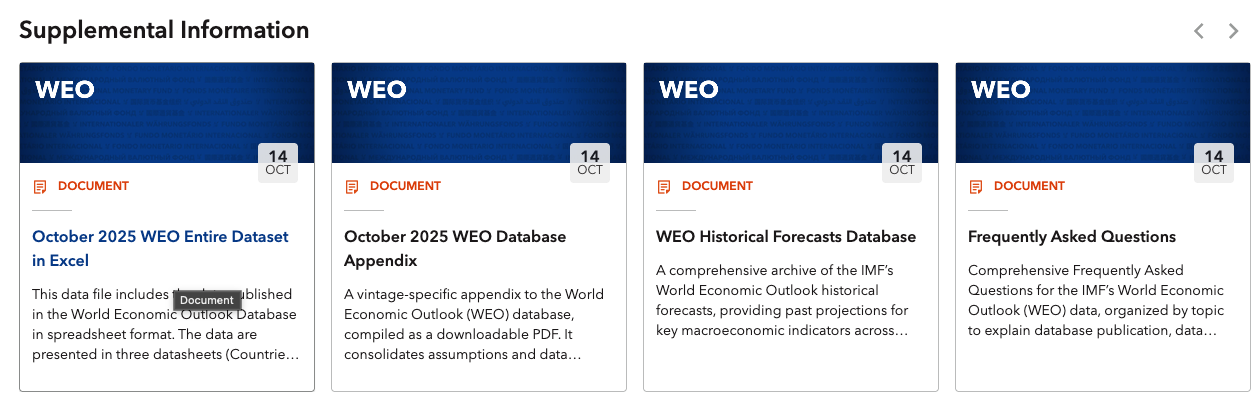

In [46]:
file_name = "WEOOct2025all.xlsx"
df = pd.read_excel(file_name, sheet_name='Countries')

---
## Section 3: Demonstration

### 3.1 Data Cleaning

The raw file has one row per country and indicator, with years as columns. The `prep_data()` function reshapes it so Plotly can use it. It converts the year columns into rows, and turns the indicators into separate columns with short names like `gdp_growth` and `inflation`.

Specifically, I use five indicators:
- real GDP growth (%),
- CPI inflation (%),
- nominal GDP (USD billions),
- GDP per capita (USD), and
- government gross debt (% of GDP).



In [47]:
def prep_data(df):
    # filter out unnecessary data
    index_cols = ["COUNTRY.ID", "COUNTRY", "INDICATOR", "UNIT", "SCALE", "LATEST_ACTUAL_ANNUAL_DATA"]

    year_cols = sorted([col for col in df.columns if isinstance(col, (int, float))])

    target_indicators = [
        "Gross domestic product (GDP), Constant prices, Percent change",
        "All Items, Consumer price index (CPI), Period average, percent change",
        "Gross domestic product (GDP), Current prices, US dollar",
        "Gross domestic product (GDP), Current prices, Per capita, US dollar",
        "Gross debt, General government, Percent of GDP"
    ]

    df_T = df.set_index(index_cols)[year_cols].stack().reset_index()
    df_T.columns = index_cols + ["year", "value"]

    df_T["value"] = pd.to_numeric(df_T["value"], errors="coerce")
    df_T["year"] = df_T["year"].astype(int)

    df_filtered = df_T[df_T["INDICATOR"].isin(target_indicators)].copy()
    grouped_df = df_filtered.set_index(["COUNTRY.ID", "COUNTRY", "year", "INDICATOR"])["value"]

    df_final = grouped_df.unstack()
    df_final = df_final.reset_index()
    df_final.columns.name = None

    # Replace column names with shorter names
    col_names = ["COUNTRY.ID", "COUNTRY"] + target_indicators
    abbrv_list = ["country_id", "country", "gdp_growth", "inflation", "gdp_usd", "gdp_per_capita_usd", "gov_debt_pct_gdp"]
    abbrv_dict = dict(zip(col_names, abbrv_list))

    df_final = df_final.rename(columns=abbrv_dict)

    return df_final


### 3.1 Data Cleaning (continue)

The code does not use a fixed country list. It picks countries that make up the top 70% of world GDP in 2000 and 2024. This includes countries that were big before, like Japan, and countries that grew later, like China and India. The result is 13 countries:
- USA, CHN, DEU, JPN, IND,
- GBR, FRA, ITA, CAN, BRA,
- RUS, KOR, MEX.

In [48]:
def get_top_share_country(df, year, threshold_pct=70):
    threshold = threshold_pct/100

    df_year = df[df["year"] == year].copy()
    df_year = df_year.dropna(subset=['gdp_usd'])
    df_year = df_year.sort_values("gdp_usd", ascending=False).reset_index(drop=True)

    gdp_total = df_year['gdp_usd'].sum()
    df_year['share'] = df_year['gdp_usd'] / gdp_total
    df_year['cum_share'] = df_year['share'].cumsum()

    top_share_index = df_year[df_year['cum_share'] <= threshold]['country_id'].tolist()

#    if len(top_share_index) < len(df_year):
    top_share_index.append(df_year.iloc[len(top_share_index)]["country_id"])

    return top_share_index


In [49]:
def get_focus_country_index(df, base_year=2000, current_year=2024, threshold_pct=70):
    base_index = get_top_share_country(df, base_year, threshold_pct)
    current_index = get_top_share_country(df, current_year, threshold_pct)

    focus_index = base_index.copy()

    for country_index in current_index:
        if country_index not in focus_index:
            focus_index.append(country_index)

    return focus_index


In [50]:
def create_line_df(df_focus, country_id, start_year=2000, end_year=2024):
    line_df = df_focus[df_focus["country_id"] == country_id].copy()

    line_df = line_df[
        (line_df["year"] >= start_year) & (line_df["year"] <= end_year)
    ]

    line_df = line_df.sort_values("year")

    line_df = line_df.dropna(
        subset=["gdp_growth", "inflation"],
        how="all"
    )

    return line_df


In [51]:
def create_scatter_df(df_focus, year=2024):
    scatter_df = df_focus[df_focus["year"] == year].copy()
    scatter_df = scatter_df.dropna(subset=["gdp_growth", "inflation", "gdp_usd"])
    return scatter_df

In [52]:
def create_debt_df(df_focus, year=2024):
    debt_df = df_focus[df_focus["year"] == year].copy()
    debt_df = debt_df.dropna(subset=["gdp_per_capita_usd", "gov_debt_pct_gdp"])
    return debt_df

In [53]:
def create_map_df(df, year=2024):
    map_df = df[df["year"] == year].copy()
    map_df = map_df.dropna(subset=["gdp_growth"])
    return map_df

In [54]:
def get_default_country_index(scatter_df):
    temp = scatter_df.sort_values("gdp_usd", ascending=False)
    return temp.iloc[0]["country_id"]

In [55]:
df = prep_data(df)

In [56]:
BASE_YEAR = 2000
CURRENT_YEAR = 2024
GDP_COVERAGE_THRESHOLD = 70

focus_country_index = get_focus_country_index(
    df,
    base_year=BASE_YEAR,
    current_year=CURRENT_YEAR,
    threshold_pct=GDP_COVERAGE_THRESHOLD
)

df_focus = df[df["country_id"].isin(focus_country_index)].copy()


In [57]:
scatter_df = create_scatter_df(df_focus, year=CURRENT_YEAR)
debt_df = create_debt_df(df_focus, year=CURRENT_YEAR)
map_df = create_map_df(df, year=CURRENT_YEAR)
default_country_id = get_default_country_index(scatter_df)

line_df = create_line_df(
    df_focus,
    country_id=default_country_id,
    start_year=BASE_YEAR,
    end_year=CURRENT_YEAR
)

In [58]:
fig_scatter = px.scatter(
    scatter_df,
    x="gdp_growth",
    y="inflation",
    size="gdp_usd",
    hover_name="country",
    text="country",
    custom_data=["country_id"],
    size_max=50,
    title="Growth vs Inflation (2024)",
    labels={
        "gdp_growth": "Real GDP growth (%)",
        "inflation": "Inflation (%)"
    }
)


In [59]:
fig_line = px.line(
    line_df,
    x="year",
    y=["gdp_growth", "inflation"],
    markers=True,
    title=f"GDP Growth & Inflation Over Time: {line_df['country'].iloc[0]}",
    labels={
        "year": "Year",
        "value": "Percent",
        "variable": "Indicator"
    }
)

In [60]:
fig_debt = px.scatter(
    debt_df,
    x="gdp_per_capita_usd",
    y="gov_debt_pct_gdp",
    hover_name="country",
    text="country",
    custom_data=["country_id"],
    title="GDP per Capita vs Government Debt (2024)",
    labels={
        "gdp_per_capita_usd": "GDP per capita (USD)",
        "gov_debt_pct_gdp": "Government debt (% of GDP)"
    }
)


In [61]:
fig_map = px.choropleth(
    map_df,
    locations="country_id",
    locationmode="ISO-3",
    color="gdp_growth",
    range_color=[-5, 10],
    hover_name="country",
    custom_data=["country_id"],
    title="Global Real GDP Growth (2024)",
    labels={"gdp_growth": "Real GDP growth (%)"}
)


In [62]:
H, W = 500, 1500

fig_map.update_layout(margin=dict(l=0, r=0, t=30, b=0), dragmode=False, height=H, width=W).show()
fig_scatter.update_traces(textposition="top center").update_layout(yaxis_range=[-2, 16], height=H, width=W).show()
fig_debt.update_traces(textposition="top center").update_layout(yaxis_range=[0, 300], height=H, width=W).show()
fig_line.update_layout(margin=dict(l=0, r=0, t=30, b=0), height=H, width=W).show()

### 3.3 Building the Dashboard

I build the dashboard one chart at a time, then add interactivity at the end.

In [64]:
# Map Plot
fig_map.update_layout(margin=dict(l=0, r=0, t=30, b=0), dragmode=False, height=H, width=W).show()


# Single interactive Chart (Line)
country_options = (
    scatter_df
    .sort_values("gdp_usd", ascending=False)
    [["country", "country_id"]]
    .apply(lambda r: (r["country"], r["country_id"]), axis=1)
    .tolist()
)

def show_line(country_id=widgets.Dropdown(options=country_options, description="Country:")):
    line_df = create_line_df(df_focus, country_id=country_id,
                       start_year=BASE_YEAR, end_year=CURRENT_YEAR)
    px.line(
        line_df, x="year", y=["gdp_growth", "inflation"], markers=True,
        title=f"GDP Growth & Inflation — {line_df['country'].iloc[0]}",
        labels={"year": "Year", "value": "Percent (%)", "variable": ""},
    ).update_layout(height=H, width=W).show()

interact(show_line)


# Multi-chart Interactivity
slider = widgets.IntSlider(min=2000, max=2024, step=1, value=2024, description="Year:")

def show_scatter(year):
    scatter_df = create_scatter_df(df_focus, year=year)
    px.scatter(
        scatter_df, x="gdp_growth", y="inflation", size="gdp_usd",
        hover_name="country", text="country", size_max=50,
        title=f"Growth vs Inflation — {year}",
        labels={"gdp_growth": "Real GDP growth (%)", "inflation": "Inflation (%)"},
    ).update_traces(textposition="top center").update_layout(yaxis_range=[-4, 18], height=H, width=W).show()

def show_debt(year):
    debt_df = create_debt_df(df_focus, year=year)
    px.scatter(
        debt_df, x="gdp_per_capita_usd", y="gov_debt_pct_gdp",
        hover_name="country", text="country",
        title=f"GDP per Capita vs Government Debt — {year}",
        labels={"gdp_per_capita_usd": "GDP per capita (USD)", "gov_debt_pct_gdp": "Government debt (% of GDP)"},
    ).update_traces(textposition="top center").update_layout(yaxis_range=[0, 300], height=H, width=W).show()

out_scatter = interactive_output(show_scatter, {"year": slider})
out_debt = interactive_output(show_debt, {"year": slider})

display(slider, out_scatter, out_debt)

interactive(children=(Dropdown(description='Country:', options=(('United States', 'USA'), ("China, People's Re…

IntSlider(value=2024, description='Year:', max=2024, min=2000)

Output()

Output()

---
## Section 4: Findings from the Analysis
- Japan has the highest government debt (Over 200% of GDP) but very low growth and inflation. (Shown in GDP per Capita vs Government Debt)
- India and China have the highest growth, but also high inflation. The bubble chart shows them in the top-right area. (Shown in Growth vs Inflation)
- In 2009, China barely slowed while Russia dropped sharply. In 2020, the US had one of the steepest drops. (Shown in GDP Growth & Inflation)

Note: GDP is in nominal US dollars, so the numbers may be affected by exchange rates.

---

## Section 5: Deployment & Troubleshooting

- Choropleth map is blank — check that `locationmode="ISO-3"` is set in `px.choropleth()`.
- `FileNotFoundError:` — the excel file "WEOOct2025all.xlsx" needs to be in the same folder as the notebook. Download from the IMF link in "Data Loading" section at the very top.
- `openpyxl` missing or outdated — run `!pip install --upgrade openpyxl` and restart the kernel.